<a href="https://colab.research.google.com/github/trLynn/ckd_prediction_model/blob/main/CKD(Logistic_Regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import kagglehub
import os
import pandas as pd

# Download dataset
path = kagglehub.dataset_download("miadul/kidney-function-health-dataset")

# Check files
print(os.listdir(path))

# Load dataset (update filename if needed)
df = pd.read_csv(os.path.join(path, "kidney_dataset.csv"))

df.head()

Using Colab cache for faster access to the 'kidney-function-health-dataset' dataset.
['kidney_dataset.csv']


,Creatinine,BUN,GFR,Urine_Output,Diabetes,Hypertension,Age,Protein_in_Urine,Water_Intake,Medication,CKD_Status
0,0.788803,8.386869,102.161787,1632.649387,0,0,27.682074,106.700203,1.570370,NaN,0
1,3.413970,53.688796,50.071257,935.540516,1,0,33.122208,410.008362,3.425287,ACE Inhibitor,1
2,0.647645,7.466540,89.451831,1774.553846,1,1,55.832284,123.336925,1.123301,Diuretic,0
3,0.795508,12.516821,99.872180,2360.602980,0,0,32.391900,116.098870,3.086846,ACE Inhibitor,0
4,0.869010,19.855960,86.110182,1987.750901,0,1,66.689515,55.668760,2.174980,ARB,0


###Check dataset size

In [18]:
print("Shape of dataset:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Shape of dataset: (5000, 11)
Number of rows: 5000
Number of columns: 11


###View column names

In [19]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Creatinine', 'BUN', 'GFR', 'Urine_Output', 'Diabetes', 'Hypertension', 'Age', 'Protein_in_Urine', 'Water_Intake', 'Medication', 'CKD_Status']


###Check data types

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Creatinine        5000 non-null   float64
 1   BUN               5000 non-null   float64
 2   GFR               5000 non-null   float64
 3   Urine_Output      5000 non-null   float64
 4   Diabetes          5000 non-null   int64  
 5   Hypertension      5000 non-null   int64  
 6   Age               5000 non-null   float64
 7   Protein_in_Urine  5000 non-null   float64
 8   Water_Intake      5000 non-null   float64
 9   Medication        2013 non-null   object 
 10  CKD_Status        5000 non-null   int64  
dtypes: float64(7), int64(3), object(1)
memory usage: 429.8+ KB


###Generate summary statistics

In [21]:
df.describe()

,Creatinine,BUN,GFR,Urine_Output,Diabetes,Hypertension,Age,Protein_in_Urine,Water_Intake,CKD_Status
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,1.994088,30.780063,73.251883,1664.302800,0.294000,0.378200,50.048733,537.053851,2.504335,0.263000
std,2.027013,31.148341,31.972399,599.384655,0.455637,0.484986,14.492020,817.510451,0.868925,0.440306
min,0.600040,7.007732,5.000000,400.502554,0.000000,0.000000,18.000000,50.010471,1.000810,0.000000
25%,0.801333,11.367599,53.036801,1105.890821,0.000000,0.000000,40.190016,83.692533,1.744138,0.000000
50%,1.007629,15.878566,89.555882,1814.499690,0.000000,0.000000,49.942824,119.492591,2.511710,0.000000
75%,2.163997,40.636666,93.989273,2146.441778,1.000000,1.000000,59.761132,588.428649,3.268812,1.000000
max,7.996428,119.931652,105.451432,2499.939696,1.000000,1.000000,90.000000,2997.724192,3.998043,1.000000


In [22]:
df.describe(include='all')

,Creatinine,BUN,GFR,Urine_Output,Diabetes,Hypertension,Age,Protein_in_Urine,Water_Intake,Medication,CKD_Status
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,2013,5000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ACE Inhibitor,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1013,NaN
mean,1.994088,30.780063,73.251883,1664.302800,0.294000,0.378200,50.048733,537.053851,2.504335,NaN,0.263000
std,2.027013,31.148341,31.972399,599.384655,0.455637,0.484986,14.492020,817.510451,0.868925,NaN,0.440306
min,0.600040,7.007732,5.000000,400.502554,0.000000,0.000000,18.000000,50.010471,1.000810,NaN,0.000000
25%,0.801333,11.367599,53.036801,1105.890821,0.000000,0.000000,40.190016,83.692533,1.744138,NaN,0.000000
50%,1.007629,15.878566,89.555882,1814.499690,0.000000,0.000000,49.942824,119.492591,2.511710,NaN,0.000000
75%,2.163997,40.636666,93.989273,2146.441778,1.000000,1.000000,59.761132,588.428649,3.268812,NaN,1.000000


### Check Missing values

In [23]:
# Check missing values
print(df.isnull().sum())

Creatinine             0
BUN                    0
GFR                    0
Urine_Output           0
Diabetes               0
Hypertension           0
Age                    0
Protein_in_Urine       0
Water_Intake           0
Medication          2987
CKD_Status             0
dtype: int64


###Inspect unique values in categorical columns

In [24]:
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: Medication
[nan 'ACE Inhibitor' 'Diuretic' 'ARB']


###Separate features and target

In [25]:
# Define the target (Output)
target = 'CKD_Status'

# Define the features (Input variables)
# Take all columns except CKD_Status
features = [col for col in df.columns if col != target]

x = df[features]  # Input data
y = df[target]    # Output labels
print("Target variable:", target)
print("Feature columns:")
print(features)
print(x)
print(y)

Target variable: CKD_Status
Feature columns:
['Creatinine', 'BUN', 'GFR', 'Urine_Output', 'Diabetes', 'Hypertension', 'Age', 'Protein_in_Urine', 'Water_Intake', 'Medication']
      Creatinine        BUN         GFR  Urine_Output  Diabetes  Hypertension  \
0       0.788803   8.386869  102.161787   1632.649387         0             0   
1       3.413970  53.688796   50.071257    935.540516         1             0   
2       0.647645   7.466540   89.451831   1774.553846         1             1   
3       0.795508  12.516821   99.872180   2360.602980         0             0   
4       0.869010  19.855960   86.110182   1987.750901         0             1   
...          ...        ...         ...           ...       ...           ...   
4995    4.048737  53.094020   24.964596   1179.120228         1             1   
4996    0.787392   7.598859   94.228637   2029.623102         0             1   
4997    1.177967  10.198228   89.099101   2463.843638         0             1   
4998    1.18979

###Evaluating Target Class Imbalance

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 2. Target distribution (CKD_Status)
print("="*50)
print("Target Distribution (CKD_Status)")
print("="*50)
target_counts = df['CKD_Status'].value_counts()
target_percent = df['CKD_Status'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': target_counts, 'Percentage (%)': target_percent}))



Target Distribution (CKD_Status)
            Count  Percentage (%)
CKD_Status                       
0            3685            73.7
1            1315            26.3


In [27]:
# Check imbalance ratio
ratio = target_counts[0] / target_counts[1] if 1 in target_counts else np.nan
print(f"\nImbalance ratio (0 / 1): {ratio:.2f}")
if ratio > 1.5 or ratio < 0.67:
    print("→ Class imbalance detected. Consider using class_weight or SMOTE later.")
else:
    print("→ Classes are relatively balanced.")



Imbalance ratio (0 / 1): 2.80
→ Class imbalance detected. Consider using class_weight or SMOTE later.


In [28]:
# 1. Handle Missing Values in 'Medication' first
# Healthy patients often have 'NaN', we should name them 'None'
df['Medication'] = df['Medication'].fillna('None')

# 2. Use One-Hot Encoding for 'Medication'
# This creates separate 0/1 columns for each drug type
df = pd.get_dummies(df, columns=['Medication'])
# All numeric columns correlation with target
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude target if you want
numeric_cols_no_target = [col for col in numeric_cols if col != 'CKD_Status']

# Correlation matrix (only numeric)
corr_matrix_all = df[numeric_cols].corr()

# Show correlation with CKD_Status for all numeric features
corr_with_target_all = corr_matrix_all['CKD_Status'].drop('CKD_Status').sort_values(ascending=False)
print("Correlation with CKD_Status (all numeric features):")
print(corr_with_target_all)


Correlation with CKD_Status (all numeric features):
BUN                 0.888944
Creatinine          0.887267
Protein_in_Urine    0.828957
Hypertension        0.036222
Diabetes           -0.000608
Age                -0.002403
Water_Intake       -0.021147
Urine_Output       -0.852535
GFR                -0.947014
Name: CKD_Status, dtype: float64


###Exploratory Data Analysis: Outlier Quantification

In [29]:
# 1. Handle missing values FIRST (very important)
df = df.fillna(df.median(numeric_only=True))

# 2. Select numeric columns
numeric_df = df.select_dtypes(include=['number'])

# 3. Calculate IQR
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# 4. Detect outliers (BEFORE cleaning)
outliers_before = ((numeric_df < (Q1 - 1.5 * IQR)) |
                   (numeric_df > (Q3 + 1.5 * IQR)))

print("Outliers BEFORE handling:\n")
print(outliers_before.sum())

Outliers BEFORE handling:

Creatinine          842
BUN                 559
GFR                   0
Urine_Output          0
Diabetes              0
Hypertension          0
Age                  15
Protein_in_Urine    861
Water_Intake          0
CKD_Status            0
dtype: int64


In [30]:
print("\n" + "="*50)
print("Outlier Detection (Before Capping)")
print("="*50)

# Select numeric features to check for outliers (excluding target)
outlier_cols = ['Creatinine', 'BUN', 'Protein_in_Urine']

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers, lower, upper

for col in outlier_cols:
    outliers, lb, ub = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers detected (range: {lb:.2f} - {ub:.2f})")
    # IQR Capping
    df[col] = df[col].clip(lower=lb, upper=ub)
    print(f"  → After capping, min={df[col].min():.2f}, max={df[col].max():.2f}")


Outlier Detection (Before Capping)
Creatinine: 842 outliers detected (range: -1.24 - 4.21)
  → After capping, min=0.60, max=4.21
BUN: 559 outliers detected (range: -32.54 - 84.54)
  → After capping, min=7.01, max=84.54
Protein_in_Urine: 861 outliers detected (range: -673.41 - 1345.53)
  → After capping, min=50.01, max=1345.53


### Correlation Analysis

In [31]:
print("\n" + "="*50)
print("Correlation with CKD_Status (After Outlier Handling)")
print("="*50)

# Select numeric columns (excluding object type)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# All numeric features correlation with target
corr_matrix = df[numeric_cols].corr()
corr_with_target = corr_matrix['CKD_Status'].drop('CKD_Status').sort_values(ascending=False)
print(corr_with_target)


Correlation with CKD_Status (After Outlier Handling)
Creatinine          0.947950
BUN                 0.916819
Protein_in_Urine    0.905503
Hypertension        0.036222
Diabetes           -0.000608
Age                -0.002403
Water_Intake       -0.021147
Urine_Output       -0.852535
GFR                -0.947014
Name: CKD_Status, dtype: float64


### Variance Inflation Factor

In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Select features you plan to use
selected_features = ['Creatinine', 'BUN', 'Protein_in_Urine', 'Urine_Output', 'GFR']
X_selected = df[selected_features]

# Add constant
X_with_const = add_constant(X_selected)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]
print(vif_data)

            Feature         VIF
0             const  432.056781
1        Creatinine   23.155432
2               BUN    6.745719
3  Protein_in_Urine    6.192029
4      Urine_Output    4.113721
5               GFR   28.705346


###Choose final features

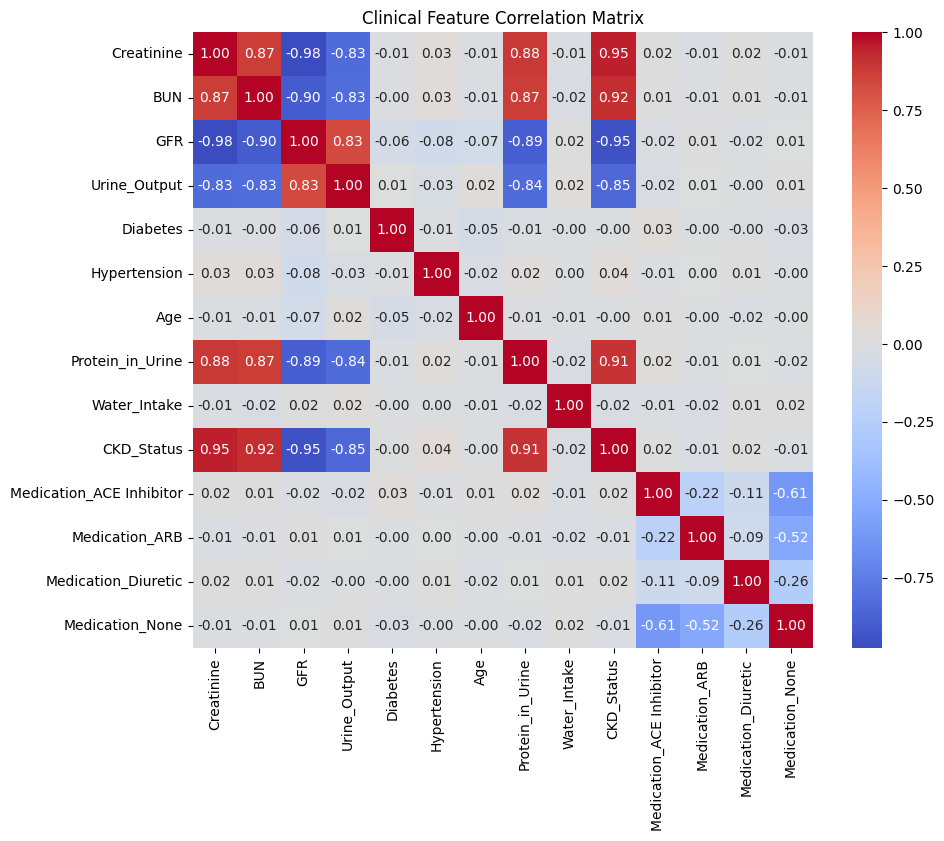

In [33]:
# Ensure df exists before plotting
if 'df' in globals():
    plt.figure(figsize=(10,8))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Clinical Feature Correlation Matrix')
    plt.savefig('correlation_heatmap.png', dpi=300)
    plt.show()
else:
    print("Error: DataFrame 'df' is not defined. Please run the data loading cells first.")

In [34]:
final_features = ['Creatinine', 'BUN', 'Protein_in_Urine', 'Urine_Output']
X_final = df[final_features]

###Feature and Target Separation, Train-Test Split, - Feature Scaling (Standardization)




In [35]:
# Import necessary modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define input features (X) and target labels (y)
X = df[final_features]          # Features selected for training
y = df['CKD_Status']            # Target column (Chronic Kidney Disease status)

# Split dataset into training and testing sets
# test_size=0.2 → 20% of data goes to testing
# random_state=42 → ensures reproducibility
# stratify=y → keeps class distribution balanced in train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Show the shape of training and testing sets
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

# Initialize the StandardScaler for feature scaling
scaler = StandardScaler()

# Fit scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to testing data
X_test_scaled = scaler.transform(X_test)

# Display first 5 rows of scaled training data
print("First 5 rows of scaled data:\n", X_train_scaled[:5])

# Check mean and standard deviation after scaling
# Mean should be ~0, Std should be ~1
print(f"\nMean after scaling: {X_train_scaled.mean():.4f}")
print(f"Standard Deviation after scaling: {X_train_scaled.std():.4f}")


Training set: (4000, 4)
Testing set: (1000, 4)
First 5 rows of scaled data:
 [[ 1.91376118  0.48252649  1.92495295 -1.93211163]
 [-0.44473044 -0.34365123 -0.61606556  0.8112983 ]
 [-0.51710271 -0.33218453 -0.59878532  0.35174407]
 [-0.63634393 -0.68936803 -0.50174944  1.00466537]
 [-0.70126711 -0.54024023 -0.63421217  0.16867089]]

Mean after scaling: 0.0000
Standard Deviation after scaling: 1.0000


###Logistic Regression

In [53]:
from sklearn.linear_model import LogisticRegression

# Create a Logistic Regression model
# - class_weight='balanced' → handles class imbalance automatically
# - max_iter=1000 → increases iterations to ensure convergence
# - random_state=42 → reproducibility
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Train (fit) the model using the scaled training data
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

###Decision Tree

In [54]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import tree

# 1. Build the Decision Tree model
# max_depth=3 → limits the tree to 3 levels (helps prevent overfitting)
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)

# 2. Train the model on the training data
dt_model.fit(X_train_scaled, y_train)

# 3. Make predictions on the test set
y_pred_dt = dt_model.predict(X_test_scaled)

###K-Nearest Neighbors

In [55]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)

pred_knn = model_knn.predict(X_test)

###Evaluate Model Performance

In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

def evaluate_model(y_true, y_pred):

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)

    return acc, prec, rec

###Evaluate all models

In [57]:
lr_results = evaluate_model(y_test, y_pred)
tree_results = evaluate_model(y_test, y_pred_dt)
knn_results = evaluate_model(y_test, pred_knn)

###Create Model Comparison Table

In [58]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "KNN"],
    "Accuracy": [lr_results[0], tree_results[0], knn_results[0]],
    "Precision": [lr_results[1], tree_results[1], knn_results[1]],
    "Recall": [lr_results[2], tree_results[2], knn_results[2]]
})

results

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.994,0.977695,1.000000
1,Decision Tree,0.992,0.984791,0.984791
2,KNN,0.980,0.932384,0.996198


###Plot Model Performance Comparison Bar Chart Comparison

Confusion Matrix Visualization

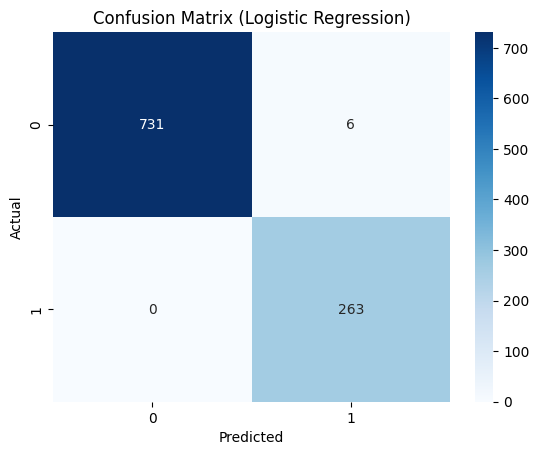

In [42]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

###Feature Importance (Decision Tree)

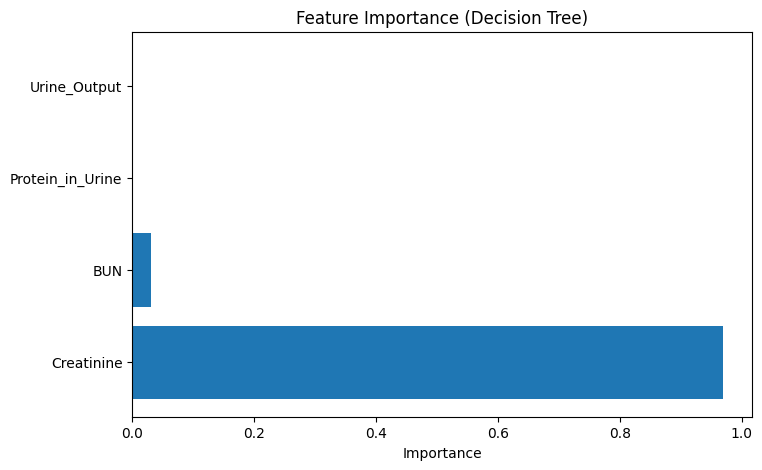

In [43]:
importance = dt_model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importance)

plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance")

plt.show()

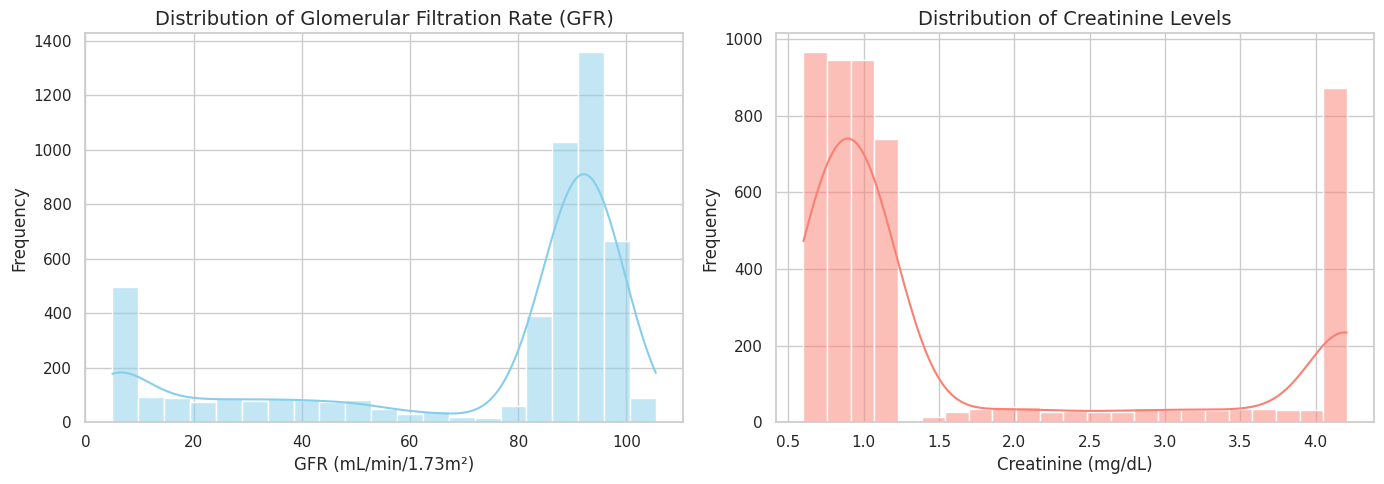

In [44]:
# Set the style of the visualization
sns.set_theme(style="whitegrid")

# Create a figure with two subplots (side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of GFR
sns.histplot(df['GFR'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Glomerular Filtration Rate (GFR)', fontsize=14)
axes[0].set_xlabel('GFR (mL/min/1.73m²)')
axes[0].set_ylabel('Frequency')

# Plot 2: Distribution of Creatinine
sns.histplot(df['Creatinine'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Creatinine Levels', fontsize=14)
axes[1].set_xlabel('Creatinine (mg/dL)')
axes[1].set_ylabel('Frequency')

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the plot
plt.savefig('clinical_features_distribution.png', dpi=300)
plt.show()

/tmp/ipykernel_2826/1580355437.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='CKD_Status', data=df, palette='viridis')


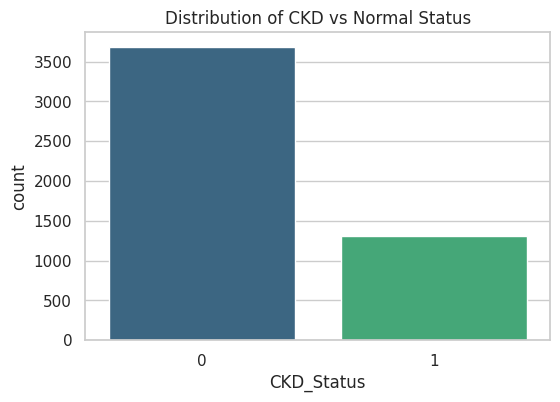

In [45]:
plt.figure(figsize=(6,4))
sns.countplot(x='CKD_Status', data=df, palette='viridis')
plt.title('Distribution of CKD vs Normal Status')
plt.savefig('target_distribution.png', dpi=300)